# Analiza demograficzna Polski z podziałem na powiaty

Dane wykorzystane w analizie pochodzą z Centralnego Banku Danych GUS (CBDG). Zostały pobrane z oficjalnych zasobów statystyki publicznej, obejmujących informacje demograficzne dla wszystkich powiatów w Polsce.
Zbiór powstał poprzez połączenie kilku niezależnych baz tematycznych dotyczących ludności, urodzeń, zgonów oraz struktury miejskiej i wiejskiej. Po integracji i oczyszczeniu danych otrzymano kompletny zestaw obejmujący wszystkie powiaty w Polsce.

Zbiór składa się z 380 rekordów (powiatów Polski)

Opis kolumn:
- **Kod** – identyfikator jednostki terytorialnej (kod TERYT)
- **Nazwa** – nazwa powiatu
- **mężczyźni** – liczba mężczyzn zamieszkujących powiat
- **kobiety** – liczba kobiet zamieszkujących powiat
- **Zgony w miastac**h – liczba zgonów na obszarach miejskich
- **Zgony na wsi** – liczba zgonów na obszarach wiejskich
- **Urodzenia w miastach** – liczba urodzeń na obszarach miejskich
- **Urodzenia na wsi** – liczba urodzeń na obszarach wiejskich
- **Ludność w miastach** – liczba mieszkańców miast
- **Ludność na wsi** – liczba mieszkańców obszarów wiejskich
- **Województwo** – województwo, do którego należy powiat


### Importowanie potrzebnych bibliotek

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt
import numpy as np

## Wczytanie danych i wstępna obróbka

In [75]:
#Wczytywanie powiatów bez prawa miasta i wstępne oczyszczanie (podział na płeć)
df=pd.read_csv(r"C:\Users\kubus\Downloads\LUDN_2914_CTAB_20260113145111.csv",sep=";")
df = df.drop(columns=["Unnamed: 4"])
df.columns = ["Kod", "Nazwa", "mężczyźni", "kobiety"]
df

,Kod,Nazwa,mężczyźni,kobiety
0,201000,Powiat bolesławiecki,42672,45350
1,202000,Powiat dzierżoniowski,45680,50636
2,203000,Powiat głogowski,41671,44295
3,204000,Powiat górowski,16287,16555
4,205000,Powiat jaworski,23407,24437
...,...,...,...,...
309,3214000,Powiat stargardzki,58448,60693
310,3215000,Powiat szczecinecki,35781,37675
311,3216000,Powiat świdwiński,21524,22276
312,3217000,Powiat wałecki,24616,25850


In [76]:
#Wczytywanie danych powiatów na praiwe miasta i wstępne oczyszczanie danych (podział na płeć)
df1=pd.read_csv("miastaludnosc.csv",sep=";")
df1 = df1.drop(columns=["Unnamed: 4"])
df1.columns = ["Kod", "Nazwa", "mężczyźni", "kobiety"]

In [77]:
#Łączenie tabel dodawanie wierszy (wszystkie powiaty)
df = pd.concat([df, df1], ignore_index=True)
df

,Kod,Nazwa,mężczyźni,kobiety
0,201000,Powiat bolesławiecki,42672,45350
1,202000,Powiat dzierżoniowski,45680,50636
2,203000,Powiat głogowski,41671,44295
3,204000,Powiat górowski,16287,16555
4,205000,Powiat jaworski,23407,24437
...,...,...,...,...
375,3063000,Powiat m. Leszno,28856,32127
376,3064000,Powiat m. Poznań,253387,289960
377,3261000,Powiat m. Koszalin,49242,55406
378,3262000,Powiat m. Szczecin,186303,206725


In [78]:
#Wczytywanie powiatów i wstępne oczyszczanie (zgony w miastach na wsi)
df1=pd.read_csv(r"C:\Users\kubus\Downloads\LUDN_3992_CTAB_20260113145603.csv",sep=";")
df1 = df1.drop(columns=["Unnamed: 4"])
df1.columns = ["Kod","Nazwa","Zgony w miastach","Zgony na wsi"]

In [79]:
df=df.merge(df1,on=["Kod", "Nazwa"],how="inner")

In [80]:
#Wczytywanie powiatów i wstępne oczyszczanie (urodzenia w miastach na wsi)
df1=pd.read_csv(r"C:\Users\kubus\Downloads\LUDN_3992_CTAB_20260113145740.csv",sep=";")
df1 = df1.drop(columns=["Unnamed: 4"])
df1.columns = ["Kod","Nazwa","Urodzenia w miastach","Urodzenia na wsi"]

In [81]:
df=df.merge(df1,on=["Kod", "Nazwa"],how="inner")

In [82]:
#Wczytywanie powiatów i wstępne oczyszczanie (ludność w miastach na wsi)
df1=pd.read_csv(r"C:\Users\kubus\Downloads\LUDN_1336_CTAB_20260113150306.csv",sep=";")
df1 = df1.drop(columns=["Unnamed: 4"])
df1.columns = ["Kod","Nazwa","Ludność w miastach","Ludność na wsi"]

In [83]:
df=df.merge(df1,on=["Kod", "Nazwa"],how="inner")

In [84]:
#Wczytywanie powiatów i wstępne oczyszczanie (podział na województwa)
df1=pd.read_csv("population_2019.csv",sep=",")
cols_to_drop = [1,2, 4, 5, 6, 7]
df1 = df1.drop(df1.columns[cols_to_drop], axis=1)
df1.columns = ["Kod","Wojewodztwo"]
df1 = df1.drop_duplicates()
df1

,Kod,Wojewodztwo
0,26100,Dolnośląskie
96,26200,Dolnośląskie
192,26400,Dolnośląskie
288,26500,Dolnośląskie
384,20100,Dolnośląskie
...,...,...
65336,321300,Zachodniopomorskie
65528,321400,Zachodniopomorskie
65720,321500,Zachodniopomorskie
65912,321600,Zachodniopomorskie


In [85]:
#Ujednolicenie kodów oraz łączenie tabel
df["Kod"] = df["Kod"] // 10
df=df.merge(df1,on=["Kod"],how="inner")

### Gotowy zbiór danych zawierający wszystkie potrzebne dane

In [86]:
df

,Kod,Nazwa,mężczyźni,kobiety,Zgony w miastach,Zgony na wsi,Urodzenia w miastach,Urodzenia na wsi,Ludność w miastach,Ludność na wsi,Wojewodztwo
0,20100,Powiat bolesławiecki,42672,45350,541,492,297,375,41488,46534,Dolnośląskie
1,20200,Powiat dzierżoniowski,45680,50636,1194,285,447,144,75339,20977,Dolnośląskie
2,20300,Powiat głogowski,41671,44295,706,205,408,165,63240,22726,Dolnośląskie
3,20400,Powiat górowski,16287,16555,173,291,78,137,13553,19289,Dolnośląskie
4,20500,Powiat jaworski,23407,24437,347,269,172,157,25738,22106,Dolnośląskie
...,...,...,...,...,...,...,...,...,...,...,...
375,306300,Powiat m. Leszno,28856,32127,720,0,523,0,60983,0,Wielkopolskie
376,306400,Powiat m. Poznań,253387,289960,6268,0,4859,0,543347,0,Wielkopolskie
377,326100,Powiat m. Koszalin,49242,55406,1233,0,774,0,104648,0,Zachodniopomorskie
378,326200,Powiat m. Szczecin,186303,206725,5387,0,3227,0,393028,0,Zachodniopomorskie


### Sprawdzanie brakujących danych

In [87]:
df.isna().sum() #Czy dane zawierają wartości NaN

Kod                     0
Nazwa                   0
mężczyźni               0
kobiety                 0
Zgony w miastach        0
Zgony na wsi            0
Urodzenia w miastach    0
Urodzenia na wsi        0
Ludność w miastach      0
Ludność na wsi          0
Wojewodztwo             0
dtype: int64

In [88]:
df.duplicated().sum() #Czy występują duplikaty

np.int64(0)

### Statystyki zmiennych numerycznych

In [89]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols].describe().round(3)

,Kod,mężczyźni,kobiety,Zgony w miastach,Zgony na wsi,Urodzenia w miastach,Urodzenia na wsi,Ludność w miastach,Ludność na wsi
count,380.000,380.000,380.000,380.000,380.000,380.000,380.000,380.000,380.000
mean,172067.895,48108.213,51437.458,732.721,447.405,469.716,333.263,59380.732,40164.939
std,94217.025,57512.068,66322.860,1469.381,348.165,1191.509,348.077,125795.766,36766.412
min,20100.000,9379.000,9514.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,100475.000,25546.000,26698.250,221.500,259.000,124.500,146.000,18382.750,20320.250
50%,163600.000,36250.000,37605.000,370.000,414.000,224.500,262.500,30752.000,33830.500
75%,247525.000,52985.750,55413.750,706.000,599.000,423.000,422.000,57824.500,50688.250
max,326300.000,859552.000,1002793.000,20501.000,2264.000,18081.000,3340.000,1862345.000,304479.000


#### Statystyka pojedyńczej zmiennej numerycznej (Ludność)

In [104]:
hist = alt.Chart(df).mark_bar(
    color="red",opacity=0.6).encode(
    x=alt.X("Ludność:Q",bin=alt.Bin(maxbins=30),
        title="Liczba mieszkańców"),
    y=alt.Y("count()",title="Liczba powiatów"))

kde = alt.Chart(df).transform_density("Ludność",
    as_=["Ludność", "density"]).mark_line(color="black",size=2).encode(
    x="Ludność:Q",
    y=alt.Y("density:Q", title="Gęstość"))

chart = (hist + kde).resolve_scale(
    y="independent").properties(
    width=500,
    height=300,
    title="Rozkład zmiennej: Ludność")

chart


alt.LayerChart(...)

##### Wniosek: Możemy zauważyć że większość powiatów ma liczbę mieszkańców w zakresie 30tys-150tys

## Macierz korelacji zmiennych numerycznych

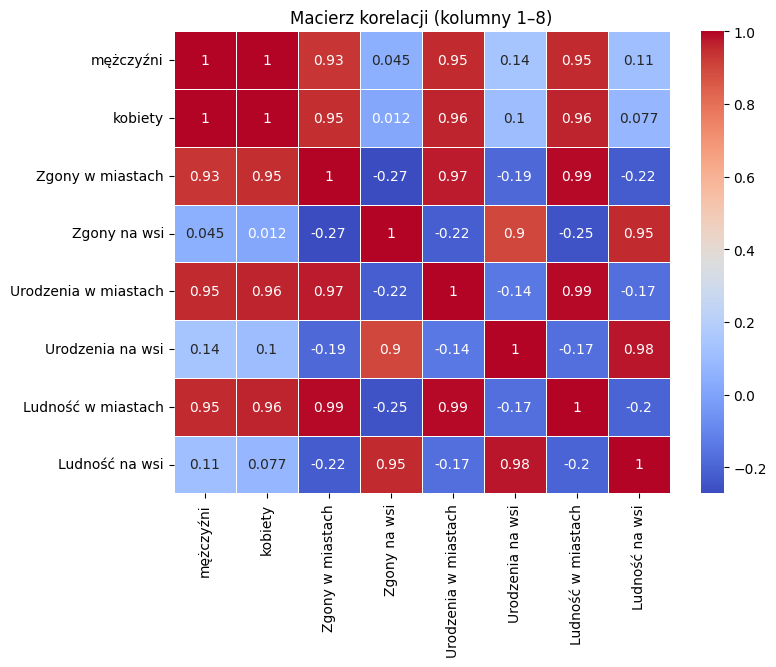

In [91]:
num_cols = df.select_dtypes(include=["int64", "float64"])
num_cols_subset = num_cols.iloc[:, 1:9]
corr = num_cols_subset.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Macierz korelacji (kolumny 1–8)")
plt.show()

##### Obecność licznych zmiennych numerycznych oraz widoczne zależności między nimi (np. silne korelacje między urodzeniami i płcią) wskazują, że zbiór jest dobrze przygotowany do analizy statystycznej, eksploracyjnej.. Nadaje się do wizualizacji, segmentacji, analizy korelacji oraz budowy wskaźników demograficznych.

### Przygotowanie danych do wykresów Altair map

In [92]:
import requests
geojson_url = "https://raw.githubusercontent.com/ppatrzyk/polska-geojson/master/powiaty/powiaty-max.geojson"
data = requests.get(geojson_url).json()
print("Liczba powiatów:", len(data["features"]))
print("\nPrzykładowe properties pierwszego powiatu:")
for item in data["features"][0]["properties"].items():
    print(item)



Liczba powiatów: 380

Przykładowe properties pierwszego powiatu:
('id', 1)
('nazwa', 'powiat ropczycko-sędziszowski')


##### Po sprawedzeniu danych uzyskałem informacje że powiady ziemskie są zapsiane w formie jak przykład powyżej natomiast miasta na prawach powiatu są zapisane w w formie powiat i następnie nazwa z dużej litery co rozróżnia je od powiatów ziemskich.

In [93]:
def normalize_powiat(name):
    n = name.strip().lower()

    if "m. " in n:
        miasto = (
            n.replace("powiat ", "")
             .replace("m. ", "")
             .strip())
        return miasto.capitalize()
    if n.startswith("powiat "):
        powiat = n.replace("powiat ", "").strip()
        return powiat
    return n
df['powiat_norm'] = df['Nazwa'].apply(normalize_powiat)

In [94]:
df['powiat_norm'].head(10)

0     bolesławiecki
1    dzierżoniowski
2         głogowski
3          górowski
4          jaworski
5        karkonoski
6    kamiennogórski
7           kłodzki
8          legnicki
9          lubański
Name: powiat_norm, dtype: object

### Konstrukcja dodatkowych zmiennych i wskaźników demograficznych

In [95]:
df["Współczynnik feminizacji"]=(df["kobiety"]/df["mężczyźni"]*100).round(2)
df["Ludność"]=df["kobiety"]+df["mężczyźni"]
df["Urodzenia"]=df["Urodzenia w miastach"]+df["Urodzenia na wsi"]
df["Zgony"]=df["Zgony w miastach"]+df["Zgony na wsi"]
df["urbanizacja"] =(df["Ludność w miastach"]/df["Ludność"]*100).round(2)
df.head(5)

,Kod,Nazwa,mężczyźni,kobiety,Zgony w miastach,Zgony na wsi,Urodzenia w miastach,Urodzenia na wsi,Ludność w miastach,Ludność na wsi,Wojewodztwo,powiat_norm,Współczynnik feminizacji,Ludność,Urodzenia,Zgony,urbanizacja
0,20100,Powiat bolesławiecki,42672,45350,541,492,297,375,41488,46534,Dolnośląskie,bolesławiecki,106.28,88022,672,1033,47.13
1,20200,Powiat dzierżoniowski,45680,50636,1194,285,447,144,75339,20977,Dolnośląskie,dzierżoniowski,110.85,96316,591,1479,78.22
2,20300,Powiat głogowski,41671,44295,706,205,408,165,63240,22726,Dolnośląskie,głogowski,106.30,85966,573,911,73.56
3,20400,Powiat górowski,16287,16555,173,291,78,137,13553,19289,Dolnośląskie,górowski,101.65,32842,215,464,41.27
4,20500,Powiat jaworski,23407,24437,347,269,172,157,25738,22106,Dolnośląskie,jaworski,104.40,47844,329,616,53.80


In [96]:
#Tworzenie osobnego df dotyczącego urbanizacji z podziałem na województwa.
urbanizacja_woj = (df.groupby("Wojewodztwo")[["Ludność w miastach", "Ludność"]].sum()
      .assign(urbanizacja=lambda x: x["Ludność w miastach"] / x["Ludność"] * 100)
      .sort_values("urbanizacja", ascending=False))
urbanizacja_woj.head(5)

,Ludność w miastach,Ludność,urbanizacja
Wojewodztwo,,,
Śląskie,3312611,4359954,75.978118
Zachodniopomorskie,1121576,1645058,68.178508
Dolnośląskie,1956710,2892067,67.657838
Mazowiecke,3566935,5511491,64.718150
Lubuskie,632507,982655,64.367148


# Wykresy

### Wykresty Altair pokazujące urbanizację z podziałem na powiat oraz urbanizację województw.

In [97]:
geo = alt.Data(url=geojson_url,format=alt.DataFormat(type='json', property='features'))

urbanizacjamapa = (alt.Chart(geo)
    .mark_geoshape(stroke='white')
    .encode(color=alt.Color('urbanizacja:Q', scale=alt.Scale(scheme='reds')),tooltip=['properties.nazwa:N', 'urbanizacja:Q'])
    .transform_calculate(powiat_norm=("replace(datum.properties.nazwa, 'powiat ', '')")) #wyłuskanie samych nazw powiatów z linku geo
    .transform_lookup(lookup='powiat_norm',from_=alt.LookupData(df, 'powiat_norm', ['urbanizacja']))
    .project('mercator')
    .properties(width=600, height=570,title="Urbanizaja powiatów mapa"))

bar = (alt.Chart(urbanizacja_woj.reset_index().head(8)).mark_bar().encode(
        x=alt.X("urbanizacja:Q", title="Urbanizacja (%)"),
        y=alt.Y("Wojewodztwo:N", sort="-x", title=""),
        color=alt.Color("urbanizacja:Q", scale=alt.Scale(scheme="reds")),
        tooltip=["Wojewodztwo:N", "urbanizacja:Q"])
    .properties(width=300,height=500,title="Najbardziej zurbanizowane województwa"))
(bar | urbanizacjamapa)


alt.HConcatChart(...)

### Wykresty Altair pokazujące współczynnik przyrostu naturalnego z podziałem na powiat oraz województwa.

In [98]:
#Współczynnik przyrostu naturalnego
df["Współczynnik przyrostu naturalnego"]=(((df["Urodzenia"]-df["Zgony"])/df["Ludność"])*1000).round(2)
przyrost_woj = (df.groupby("Wojewodztwo")["Współczynnik przyrostu naturalnego"].mean().round(2))   
MapaWspPrzyrostuNaturalnego = (alt.Chart(geo)
    .mark_geoshape(stroke='white')
    .encode(color=alt.Color('Współczynnik przyrostu naturalnego:Q', scale=alt.Scale(scheme='reds')),tooltip=['properties.nazwa:N', 'Współczynnik przyrostu naturalnego:Q'])
    .transform_calculate(powiat_norm=("replace(datum.properties.nazwa, 'powiat ', '')"))
    .transform_lookup(lookup='powiat_norm',from_=alt.LookupData(df, 'powiat_norm', ['Współczynnik przyrostu naturalnego']))
    .project('mercator')
    .properties(width=600, height=570,title="Mapa współczynnika przyrostu naturalnego"))

bar = (alt.Chart(przyrost_woj.reset_index().head(8)).mark_bar()
    .encode(x=alt.X("Współczynnik przyrostu naturalnego:Q",title="Współczynnik przyrostu naturalnego (‰)"),
        y=alt.Y("Wojewodztwo:N", sort="-x", title="",axis=alt.Axis(orient="right")),
        color=alt.Color("Współczynnik przyrostu naturalnego:Q",scale=alt.Scale(scheme="reds")),
        tooltip=["Wojewodztwo:N", "Współczynnik przyrostu naturalnego:Q"])
    .properties(width=300,height=500,title="Najwyższy współczynnik przyrostu naturalnego – województwa"))

(bar | MapaWspPrzyrostuNaturalnego)

alt.HConcatChart(...)

#### Tworzenie osodnej df dla ilości ludności w województwach

In [99]:
ludnoscwoj = (df.groupby("Wojewodztwo", as_index=False)["Ludność"].sum().sort_values("Ludność", ascending=False))
ludnoscwoj["Procent"] = (ludnoscwoj["Ludność"] / ludnoscwoj["Ludność"].sum() * 100)
ludnoscwoj.head(5)

,Wojewodztwo,Ludność,Procent
4,Mazowiecke,5511491,14.570120
14,Śląskie,4359954,11.525929
11,Wielkopolskie,3496307,9.242801
5,Małopolskie,3428929,9.064681
0,Dolnośląskie,2892067,7.645438


In [100]:
kolejnosc = (ludnoscwoj.sort_values("Ludność", ascending=True)["Wojewodztwo"].tolist())

populacjakolo = (alt.Chart(ludnoscwoj).mark_arc(innerRadius=20, stroke="white")
    .encode(theta=alt.Theta("Wojewodztwo:N",sort=kolejnosc),
        radius=alt.Radius("Ludność:Q",scale=alt.Scale(type="sqrt", zero=True)),
        color=alt.Color("Wojewodztwo:N",scale=alt.Scale(scheme="orangered",domain=kolejnosc),
            legend=alt.Legend(orient="right",title="Województwo")),
        tooltip=["Wojewodztwo:N","Ludność:Q",alt.Tooltip("Procent:Q", format=".1f")])
    .properties(width=500,height=600,title="Radialny wykres ludności wg województw"))
populacjakolo


alt.Chart(...)

##### Wniosek: Możana zauważyć że najwiecej ludzi mieszka w województwie Mazowieckim (14,6%), natomiast najmniej w województwie Opolskim (2,5%)

#### Tworzenie nowego df dla liczby zgonów i urodzeń w województwach

In [105]:
wojurzg = (df.groupby("Wojewodztwo", as_index=False)[["Zgony", "Urodzenia"]].sum().sort_values("Wojewodztwo", ascending=False))
wojurzg.head(5)

,Wojewodztwo,Zgony,Urodzenia
15,Świętokrzyskie,15787,8157
14,Śląskie,56694,31597
13,Łódzkie,33357,18163
12,Zachodniopomorskie,20427,11654
11,Wielkopolskie,38025,30478


In [102]:
longWoj = wojurzg.melt(id_vars="Wojewodztwo",value_vars=["Urodzenia", "Zgony"],var_name="Typ",value_name="Liczba")

UrodzeniaZgony = (
    alt.Chart(longWoj)
    .mark_line(point=True)
    .encode(x=alt.X("Wojewodztwo:N", sort=None),y=alt.Y("Liczba:Q"),
        color=alt.Color("Typ:N",title="",scale=alt.Scale(domain=["Urodzenia", "Zgony"],range=["red", "black"])),
        tooltip=["Wojewodztwo", "Typ", "Liczba"])
    .properties(width=700,height=400,title="Urodzenia i zgony w województwach"))

UrodzeniaZgony

alt.Chart(...)

##### Wniosek: Można zauważyć że największa róznica pomiędzy urodzeniami a zgonami jest w województwie śląskim.

#### Tworzymy osobny df z podziałem na płeć ze względu na województwa

In [132]:
plecwojewodztwo = (df.groupby("Wojewodztwo")[["mężczyźni", "kobiety"]].sum()).sort_values("kobiety",ascending=False)
plecwojewodztwo.head(5)

,mężczyźni,kobiety
Wojewodztwo,,
Mazowiecke,2638660,2872831
Śląskie,2097744,2262210
Wielkopolskie,1698837,1797470
Małopolskie,1663196,1765733
Dolnośląskie,1390230,1501837


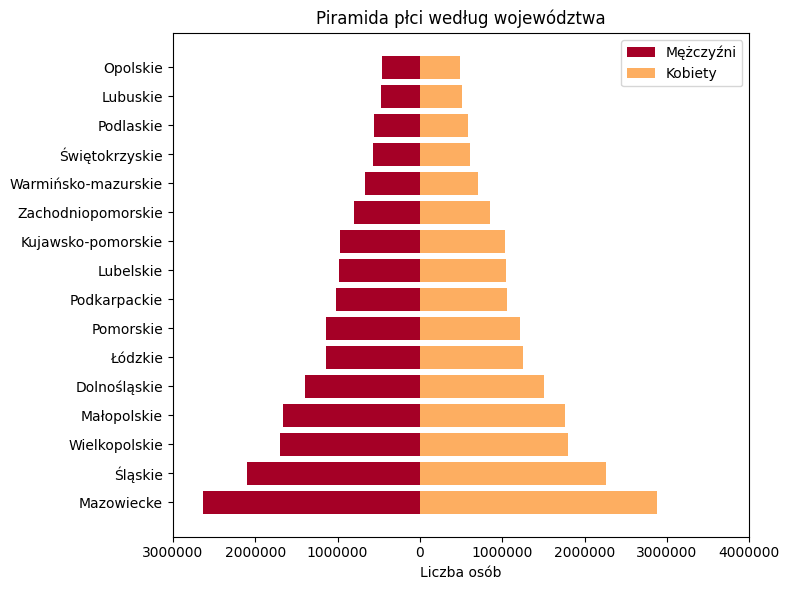

In [136]:
y = np.arange(len(plecwojewodztwo.index))

plt.figure(figsize=(8,6))
plt.barh(y, (plecwojewodztwo["mężczyźni"].values * -1), color="#A50026", label="Mężczyźni")
plt.barh(y, plecwojewodztwo["kobiety"].values, color="#FDAE61", label="Kobiety")
plt.yticks(y, plecwojewodztwo.index)
plt.xlabel("Liczba osób")
plt.title("Piramida płci według województwa")
plt.legend(loc="upper right")
xticks = plt.xticks()[0]
plt.xticks(xticks, [abs(int(x)) for x in xticks])

plt.tight_layout()
plt.show()

##### Wniosek: W każdym województwie jest mniej wiecej równy podział płci

In [138]:
wojewodztwozgur = (df.groupby("Wojewodztwo")[["Zgony na wsi", "Zgony w miastach","Urodzenia w miastach","Urodzenia na wsi"]].sum())
wojewodztwozgur.head(5)

,Zgony na wsi,Zgony w miastach,Urodzenia w miastach,Urodzenia na wsi
Wojewodztwo,,,,
Dolnośląskie,10352,25733,15392,7335
Kujawsko-pomorskie,8770,15414,8421,6640
Lubelskie,13922,11002,6957,8261
Lubuskie,3966,7689,4651,2439
Mazowiecke,22526,40095,33050,17199


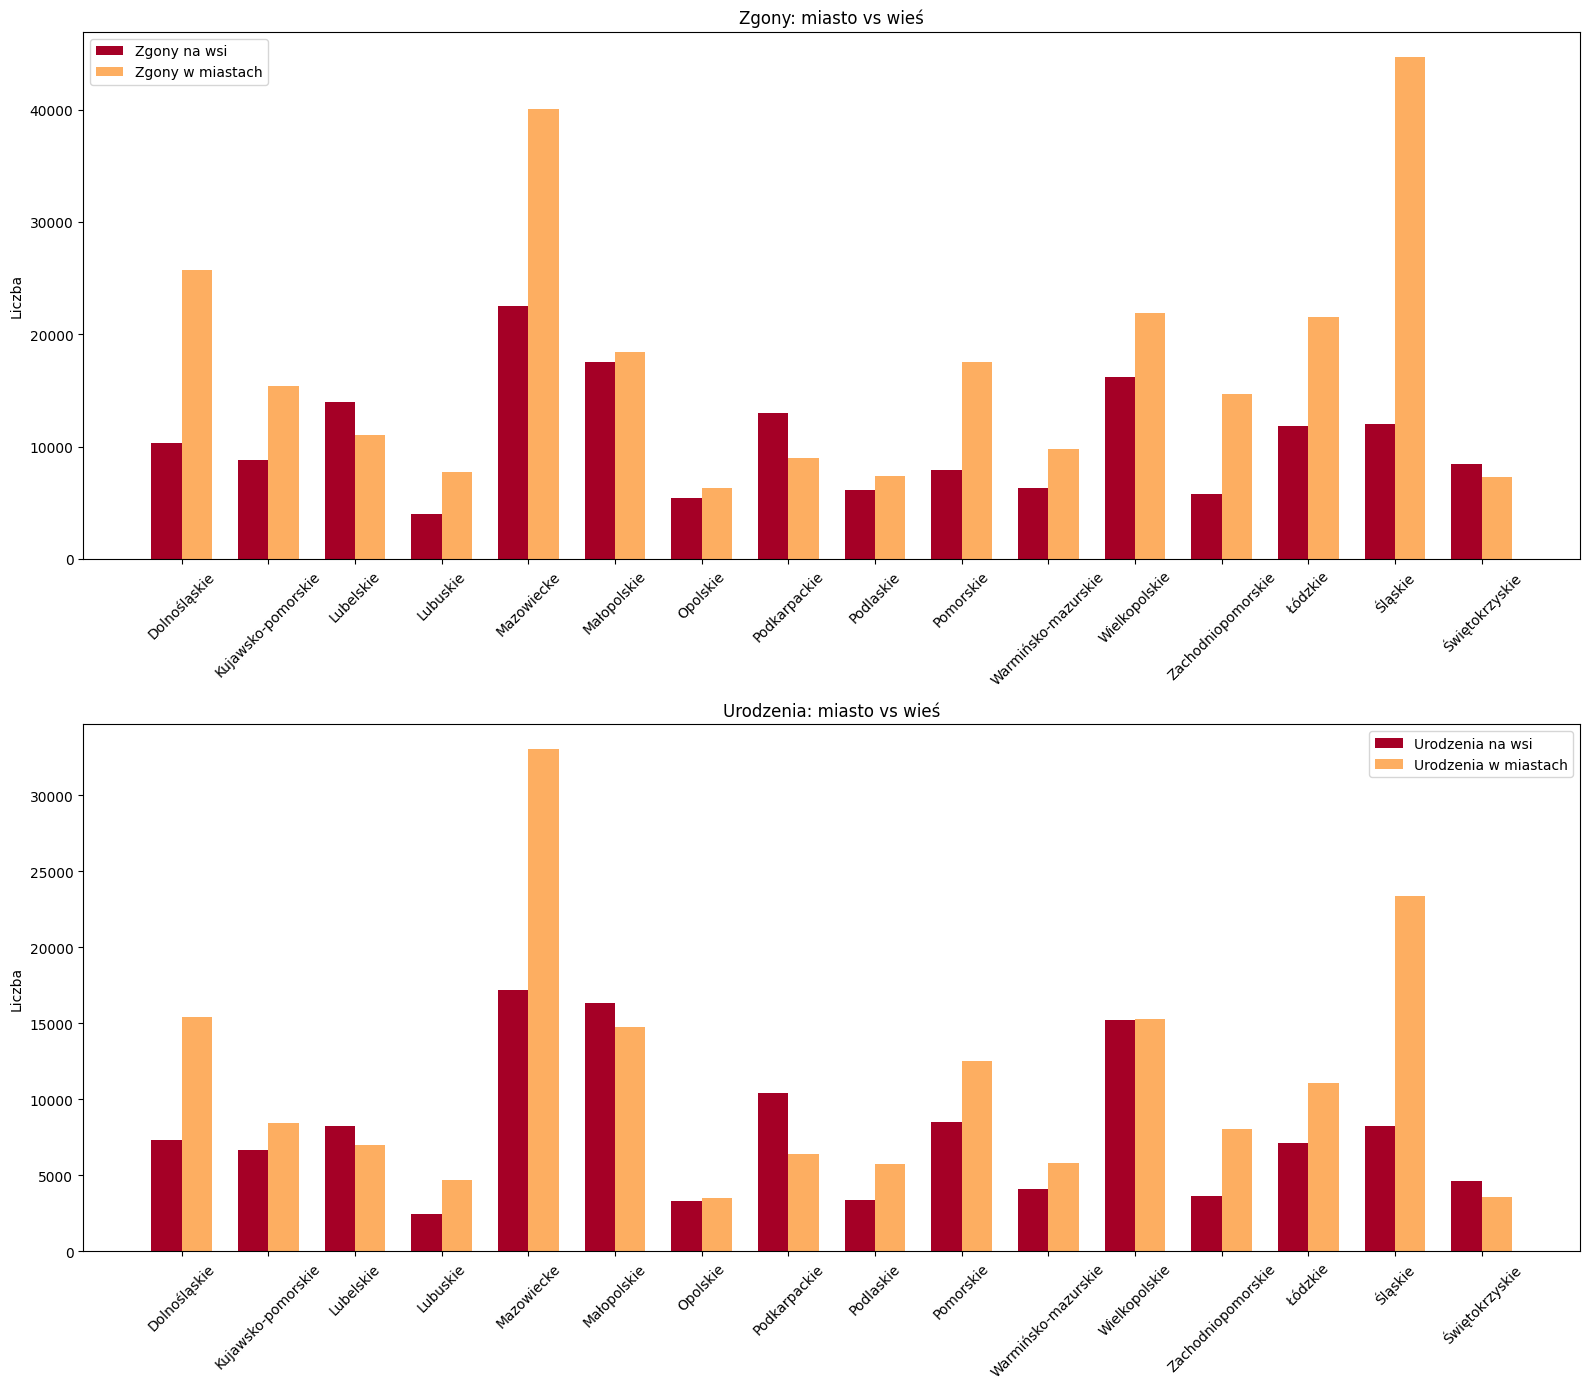

In [143]:
woj = plecwojewodztwo.index
x = np.arange(len(plecwojewodztwo.index))

fig, axes = plt.subplots(2, 1, figsize=(16,14))
axes[0].bar(x - 0.35/2, plecwojewodztwo["Zgony na wsi"], 0.35,label="Zgony na wsi", color="#A50026")
axes[0].bar(x + 0.35/2, plecwojewodztwo["Zgony w miastach"], 0.35,label="Zgony w miastach", color="#FDAE61")
axes[0].set_title("Zgony: miasto vs wieś")
axes[0].set_xticks(x)
axes[0].set_xticklabels(woj, rotation=45)
axes[0].set_ylabel("Liczba")
axes[0].legend()
axes[1].bar(x - 0.35/2, plecwojewodztwo["Urodzenia na wsi"], 0.35,label="Urodzenia na wsi", color="#A50026")
axes[1].bar(x + 0.35/2, plecwojewodztwo["Urodzenia w miastach"], 0.35,label="Urodzenia w miastach", color="#FDAE61")
axes[1].set_title("Urodzenia: miasto vs wieś")
axes[1].set_xticks(x)
axes[1].set_xticklabels(woj, rotation=45)
axes[1].set_ylabel("Liczba")
axes[1].legend()
plt.tight_layout()
plt.show()

In [157]:
wskaznik_woj = (df.groupby("Wojewodztwo")[["Zgony na wsi","Zgony w miastach","Urodzenia w miastach","Urodzenia na wsi","Ludność w miastach","Ludność na wsi"]].sum()
    .assign(
        wsk_zgony_miasto=lambda x: x["Zgony w miastach"] / x["Ludność w miastach"] * 1000,
        wsk_zgony_wies=lambda x: x["Zgony na wsi"] / x["Ludność na wsi"] * 1000,
        wsk_urodzenia_miasto=lambda x: x["Urodzenia w miastach"] / x["Ludność w miastach"] * 1000,
        wsk_urodzenia_wies=lambda x: x["Urodzenia na wsi"] / x["Ludność na wsi"] * 1000))

wskaznik_woj = wskaznik_woj.drop(wskaznik_woj.columns[[0,1,2,3,4,5]], axis=1)
wskaznik_woj.head(5)

,Zgony na wsi,Zgony w miastach,Urodzenia w miastach,Urodzenia na wsi,Ludność w miastach,Ludność na wsi,wsk_zgony_miasto,wsk_zgony_wies,wsk_urodzenia_miasto,wsk_urodzenia_wies
Wojewodztwo,,,,,,,,,,
Dolnośląskie,10352,25733,15392,7335,1956710,935357,13.151157,11.067432,7.866265,7.841926
Kujawsko-pomorskie,8770,15414,8421,6640,1172194,839458,13.149700,10.447217,7.183964,7.909866
Lubelskie,13922,11002,6957,8261,938833,1091676,11.718804,12.752868,7.410264,7.567264
Lubuskie,3966,7689,4651,2439,632507,350148,12.156387,11.326639,7.353278,6.965626
Mazowiecke,22526,40095,33050,17199,3566935,1944556,11.240743,11.584135,9.265658,8.844693


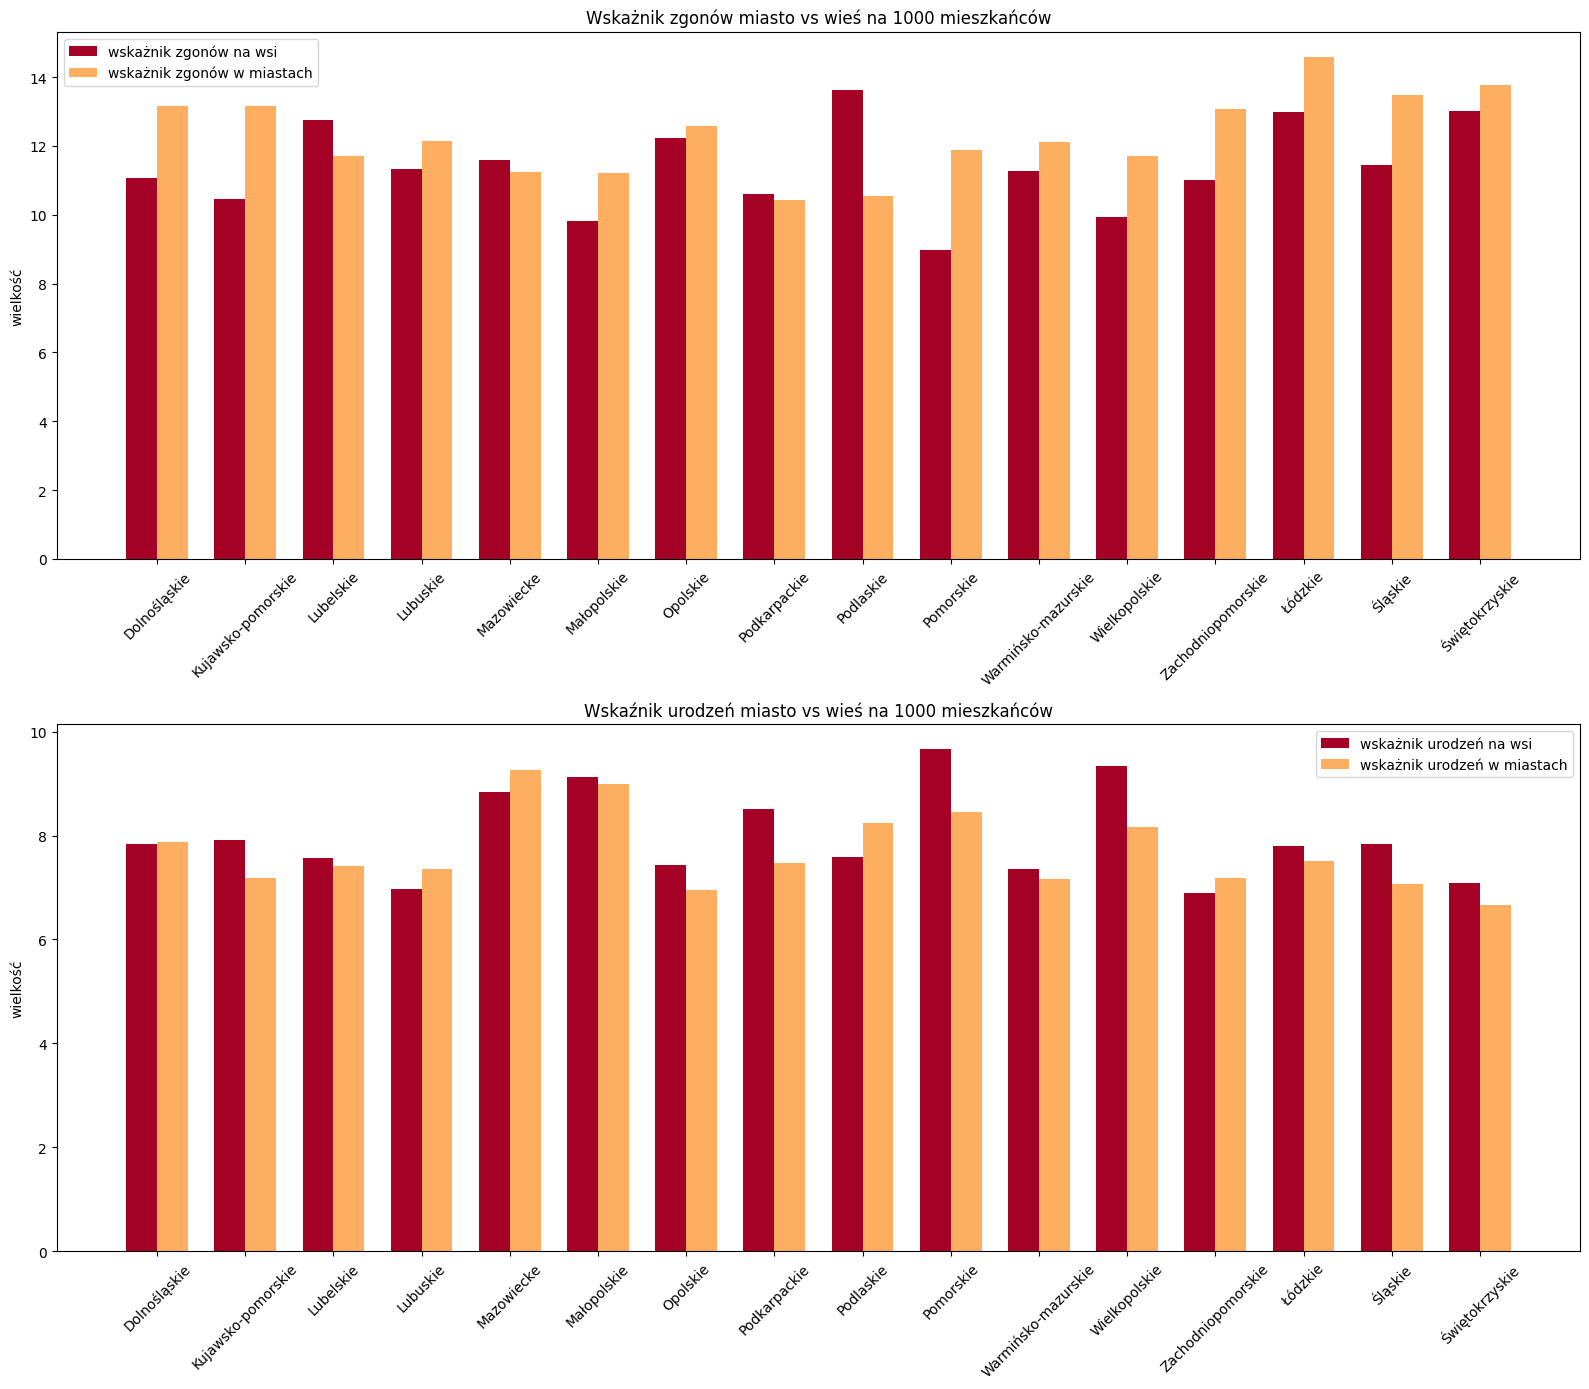

In [158]:
woj = wskaznik_woj.index
x = np.arange(len(wskaznik_woj.index))

fig, axes = plt.subplots(2, 1, figsize=(16,14))
axes[0].bar(x - 0.35/2, wskaznik_woj["wsk_zgony_wies"], 0.35,label="wskażnik zgonów na wsi", color="#A50026")
axes[0].bar(x + 0.35/2, wskaznik_woj["wsk_zgony_miasto"], 0.35,label="wskażnik zgonów w miastach", color="#FDAE61")
axes[0].set_title("Wskażnik zgonów miasto vs wieś na 1000 mieszkańców")
axes[0].set_xticks(x)
axes[0].set_xticklabels(woj, rotation=45)
axes[0].set_ylabel("wielkość")
axes[0].legend()
axes[1].bar(x - 0.35/2, wskaznik_woj["wsk_urodzenia_wies"], 0.35,label="wskażnik urodzeń na wsi", color="#A50026")
axes[1].bar(x + 0.35/2, wskaznik_woj["wsk_urodzenia_miasto"], 0.35,label="wskażnik urodzeń w miastach", color="#FDAE61")
axes[1].set_title("Wskaźnik urodzeń miasto vs wieś na 1000 mieszkańców")
axes[1].set_xticks(x)
axes[1].set_xticklabels(woj, rotation=45)
axes[1].set_ylabel("wielkość")
axes[1].legend()
plt.tight_layout()
plt.show()

In [164]:
wskaznik_woj["przyrost_miasto_1000"] = (wskaznik_woj["wsk_urodzenia_miasto"] - wskaznik_woj["wsk_zgony_miasto"])

wskaznik_woj["przyrost_wies_1000"] = (wskaznik_woj["wsk_urodzenia_wies"] - wskaznik_woj["wsk_zgony_wies"])

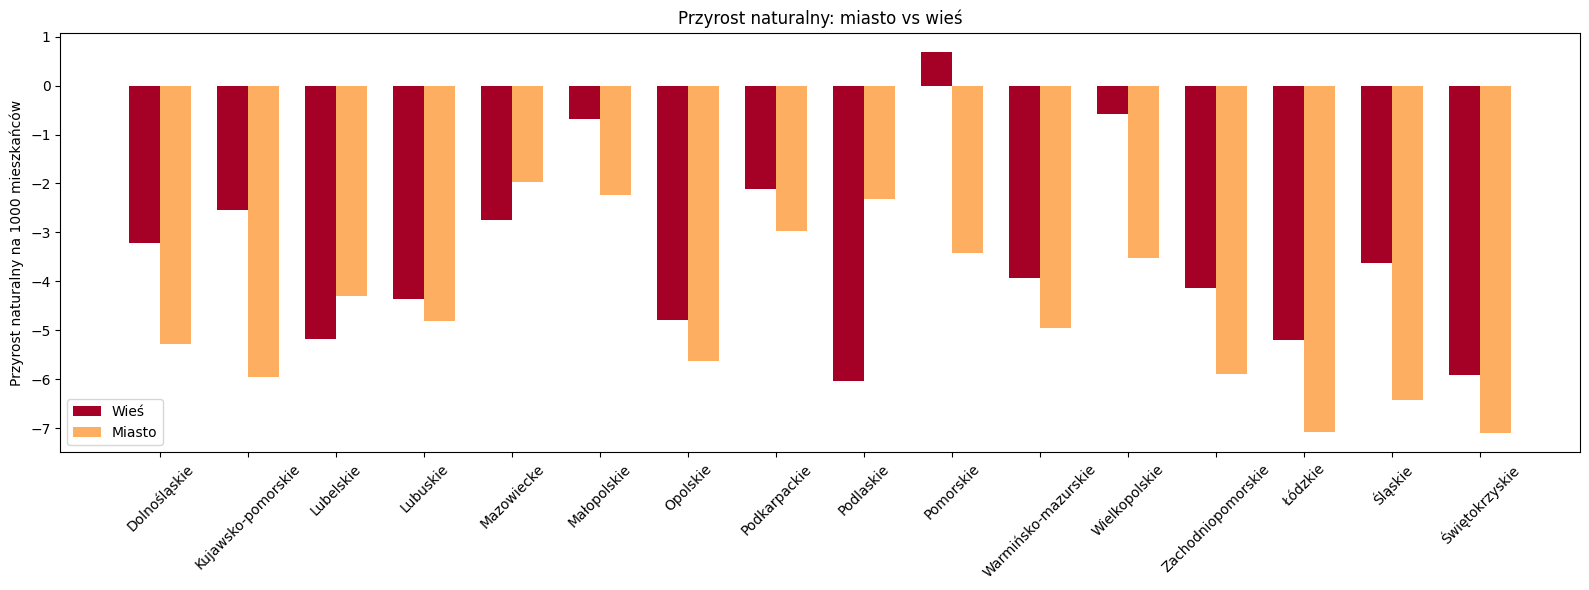

In [165]:
woj = wskaznik_woj.index
x = np.arange(len(woj))
width = 0.35
plt.figure(figsize=(16,6))
plt.bar(x - width/2, wskaznik_woj["przyrost_wies_1000"], width,label="Wieś", color="#A50026")
plt.bar(x + width/2, wskaznik_woj["przyrost_miasto_1000"], width,label="Miasto", color="#FDAE61")
plt.xticks(x, woj, rotation=45)
plt.ylabel("Przyrost naturalny na 1000 mieszkańców")
plt.title("Przyrost naturalny: miasto vs wieś")
plt.legend()
plt.tight_layout()
plt.show()

 Przyrost naturalny jest zazwyczaj wyższy na wsiach niż w miastach, ponieważ w miastach obserwuje się niższy współczynnik urodzeń i wyższy wskaźnik zgonów (tzw. ubytek naturalny), podczas gdy na wsiach sytuacja bywa odwrotna lub przynajmniej mniej negatywna. Mieszkańcy wsi częściej decydują się na dzieci, podczas gdy w miastach młodzi koncentrują się na karierze, opóźniając decyzję o rodzinie, co skutkuje ujemnym przyrostem naturalnym w aglomeracjach. 